# Desafio 1 - IEEE UnB CIS

**Candidato**: Yan Santos Rodrigues <br>

---

**Contexto**: O conjunto de dados contém informações clínicas de pacientes (idade, pressão arterial, colesterol, frequência cardíaca, etc.) com o objetivo de prever a presença de doenças cardíacas. <br>
**Dataset**: Heart Disease UCI Dataset <br>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# Lendo o csv a partir do repositório criado para o PS da IEEE
df = pd.read_csv("https://raw.githubusercontent.com/yanrdgs-dev/ps-ieee-cis/refs/heads/main/heart.csv")

display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Questão 1
"Existem valores ausentes ou inconsistentes no dataset? Se sim, escolha e justifique (em uma célula de texto) uma estratégia de tratamento." <br>

Antes de definirmos uma estratégia de tratamento, vamos investigar o conjunto de dados.
1. Buscaremos por valores nulos explícitos (`NaN`)
2. Buscaremos por valores inconsistentes (dados preenchidos, mas que fogem das regras do dicionário do Dataset)

In [3]:
print("Soma dos valores nulos:")
print(df.isnull().sum())

cols_categoricas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
print("\nValores únicos nas colunas categóricas:")
for col in cols_categoricas:
  valores = df[col].unique()
  valores.sort()
  print(f"Valores na coluna {col}: {valores}")

cols_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print("\nValores zerados em colunas numéricas:")
for col in cols_numericas:
    zeros = (df[col] == 0).sum()
    print(f"Campos em {col} igual a 0: {zeros}")

Soma dos valores nulos:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Valores únicos nas colunas categóricas:
Valores na coluna sex: [0 1]
Valores na coluna cp: [0 1 2 3]
Valores na coluna fbs: [0 1]
Valores na coluna restecg: [0 1 2]
Valores na coluna exang: [0 1]
Valores na coluna slope: [0 1 2]
Valores na coluna ca: [0 1 2 3 4]
Valores na coluna thal: [0 1 2 3]
Valores na coluna target: [0 1]

Valores zerados em colunas numéricas:
Campos em age igual a 0: 0
Campos em trestbps igual a 0: 0
Campos em chol igual a 0: 0
Campos em thalach igual a 0: 0
Campos em oldpeak igual a 0: 329


Com essa análise, revelamos os seguintes pontos:
- Não existem valores nulos explícitos. O `isnull().sum()` retornou 0 para todas as colunas.
- Não foram encontrados valores numéricos impossíveis e fora das regras do Dataset.
  - A variável `oldpeak` apresentar valores iguais a 0 é normal, pois mede a depressão do ST no eletrocardiograma, e 0 significa ausência dessa depressão.
- Detectamos erros em duas variáveis categóricas quanto ao dicionário do dataset no Kaggle:
  - `ca`: O intervalo aceito é de 0 a 3. Existem registros csom o valor 4.
  - `thal`: Os valores esperados são 1, 2 ou 3. Existem registros com o valor 0.

  ## Estratégia escolhida
  Para resolvermos esse problema, iremos primeiro substituir todos os valores 4 no `ca` e todos os valores 0 no `thal` por `NaN`. Então, iremos utilizar a **Imputação por Moda**, que é substituir esses `NaN` pelo valor mais frequente na coluna. <br>
  Escolhemos isso pois, em dados médicos, fazer o drop de valores pode ser prejudicial na hora de treinar o modelo. Já que se trata de duas variáveis categóricas, a Imputação por Moda se torna a opção mais viável.

In [9]:
# Vamos primeiro ver os registros afetados antes de tratar
print(f"Campos incorretos em ca (valor 4): {(df['ca'] == 4).sum()}")
print(f"Campos incorretos em thal (valor 0): {(df['ca'] == 0).sum()}")

# Então, substituímos os valores por NaN
df['ca'] = df['ca'].replace(4, np.nan)
df['thal'] = df['thal'].replace(0, np.nan)

# Agora, substituímos NaN pela moda.
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Pós tratamento
print("Valores únicos em ca: ", np.sort(df['ca'].unique()))
print("Valores únicos em thal: ", np.sort(df['thal'].unique()))

Campos incorretos em ca (valor 4): 0
Campos incorretos em thal (valor 0): 596
Valores únicos em ca:  [0. 1. 2. 3.]
Valores únicos em thal:  [1. 2. 3.]


# Questão 2
"Plote histogramas e boxplots das variáveis numéricas. Quais apresentam distribuição assimétrica ou outliers relevantes?" <br>
As variáveis analisadas serão: `age` (idade), `trestbps` (pressão arterial), `chol` (colesterol), `thalach` (frequência cardíaca) e `oldpeak` (depressão ST).


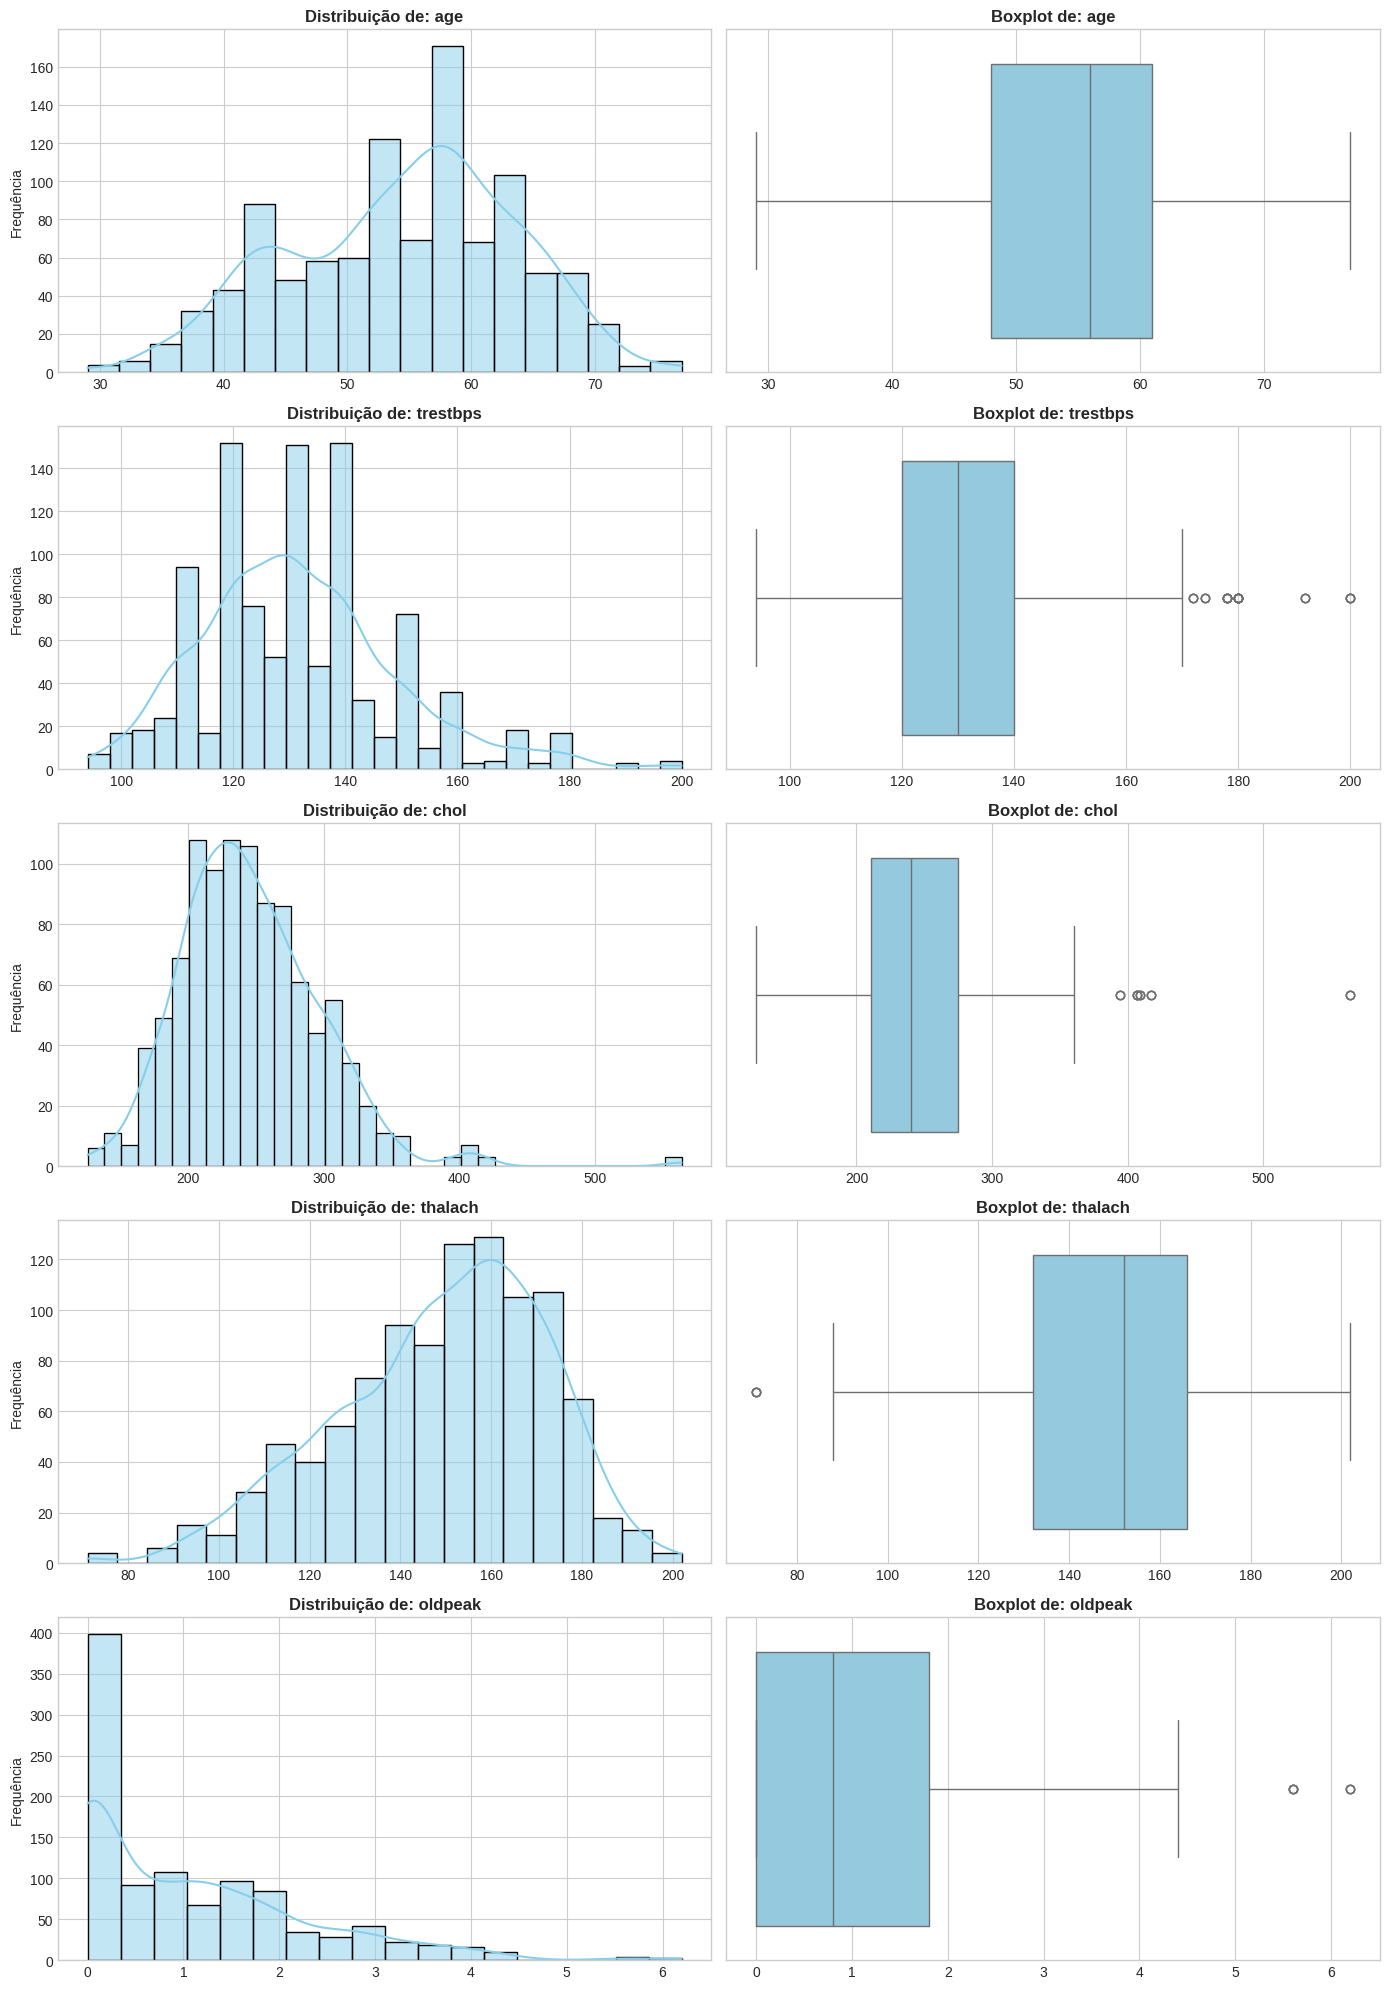

In [11]:
vars_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(nrows=len(vars_numericas), ncols=2, figsize=(14, 20))

for i, col in enumerate(vars_numericas):
  # Histograma na primeira coluna da figura
  sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black')
  axes[i, 0].set_title(f"Distribuição de: {col}", fontsize=12, fontweight='bold')
  axes[i, 0].set_ylabel("Frequência")
  axes[i, 0].set_xlabel('')

  # Boxplot na segunda coluna
  sns.boxplot(x=df[col], ax=axes[i, 1], color='skyblue')
  axes[i, 1].set_title(f"Boxplot de: {col}", fontsize=12, fontweight='bold')
  axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

# Análise dos gráficos
## Distribuições assimétricas
Quando analisamos `oldpeak` (depressão ST) e `chol` (colesterol), ambos apresentam forte assimetria positiva (ou seja, à direita). A cauda do histograma estende-se para valores mais altos, indicando que a maioria dos pacientes apresenta valores baixos, mas existe uma minoria com picos agudos nessas medições. <br><br>
Em `trestbps` (pressão arterial), vemos que aprasenta uma assimetria positiva moderada. <br><br>
Em `thalach` (frequência cardíaca máxima), percebmos que existe uma assimetria negativa (ou seja, à esquerda), o que indica que a maior parte desta amostra atinge frequências cardíacas mais elevadas durante o teste de esforço.
<br><br>
Agora, a `age` (idade) é a variável que mais se aproxima de uma distribuição normal (simétrica), com uma pequena concentração na faixa dos 50 anos aos 60 anos.